In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-10 20:59:44.294245


# Clustering

cluster without GFP etc

### Setup

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

import warnings
import session_info
import sys

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning) # Suppress Pandas PerformanceWarnings related to fragmentation

plt.rcParams['figure.figsize'] = (3, 3)

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = os.path.join(base_dir, 'data/h5ad/export_02')
clusters_dir = os.path.join(base_dir, 'clusters')
output_dir = os.path.join(base_dir, 'data/h5ad/export_03/')

os.makedirs(clusters_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

## Read adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi.h5ad'))
adata

AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p'
    obsm: 'X_scVI', 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'

## Prepare data

Importing as raw counts layer. Use log1p for rank genes.

In [6]:
print(adata.X[:5, :5].toarray())
print('')
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

[[ 0.  1.  0.  0.  0.]
 [ 4.  0. 25. 31.  0.]
 [ 2.  0.  5. 21.  0.]
 [ 0.  0.  0. 33.  0.]
 [ 0.  1.  0.  1.  0.]]

adata.X has only whole numbers: True


In [7]:
adata.layers

Layers with keys: counts, log1p, normalized_1e6

In [8]:
# Set to log1p counts layer
adata.X = adata.layers['log1p'].copy()

In [9]:
print(adata.X[:5, :5].toarray())
print('')
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))

[[0.        5.9971585 0.        0.        0.       ]
 [6.7056313 0.        8.537184  8.752257  0.       ]
 [6.6963024 0.        7.6118517 9.046559  0.       ]
 [0.        0.        0.        9.5951805 0.       ]
 [0.        8.247428  0.        8.247428  0.       ]]

adata.X has only whole numbers: False


## cluster w/o transgenes

In [10]:
transgenes = adata.var_names[adata.var_names.str.contains("Seq", case=False, na=False)]
print(transgenes)

# subset
adata = adata[:, ~adata.var_names.isin(transgenes)].copy()
print(f"Remaining genes: {adata.n_vars}")

Index(['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2'], dtype='object')
Remaining genes: 475


## Neighbors, UMAP, clustering

In [11]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 0) # Use latent representation to build neighbors graph

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
sc.tl.umap(adata, random_state = 0)

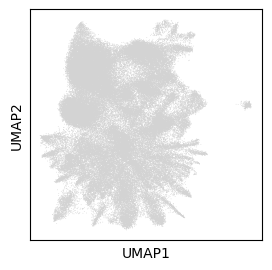

In [13]:
sc.pl.umap(adata)

In [14]:
sc.tl.leiden(adata, key_added='leiden_scVI_1', resolution=1)

/tmp/ipykernel_8406/69283825.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='leiden_scVI_1', resolution=1)


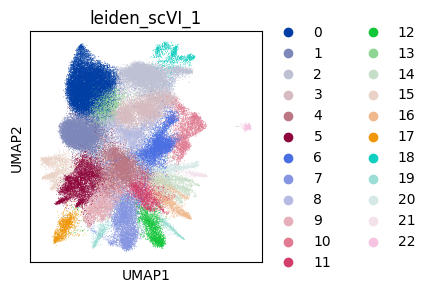

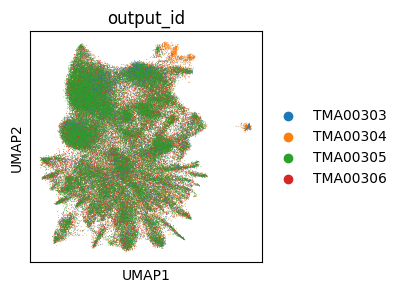

In [15]:
sc.pl.umap(adata, color = ['leiden_scVI_1'], legend_fontsize = 10)
sc.pl.umap(adata, color = ['output_id'], legend_fontsize = 10)

### Run DE rankings on clusters

In [16]:
# performance warning here but should be fine

sc.tl.rank_genes_groups(adata, groupby='leiden_scVI_1', method='wilcoxon')
df = sc.get.rank_genes_groups_df(adata, group = None)
df = df.copy()
df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
df.head(5)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Cldn19,171.366577,11.147269,0.0,0.0
1,0,Prx,165.375397,10.080978,0.0,0.0
2,0,Pllp,164.713852,10.349818,0.0,0.0
3,0,Mbp,161.652954,6.654788,0.0,0.0
4,0,Ugt8a,160.703735,9.549553,0.0,0.0


In [17]:
clusters_path = os.path.join(clusters_dir, 'rank-genes-clusters.csv')

df.to_csv(clusters_path, index=False)
print(clusters_path)

/home/workspace/projects/drg/clusters/rank-genes-clusters.csv


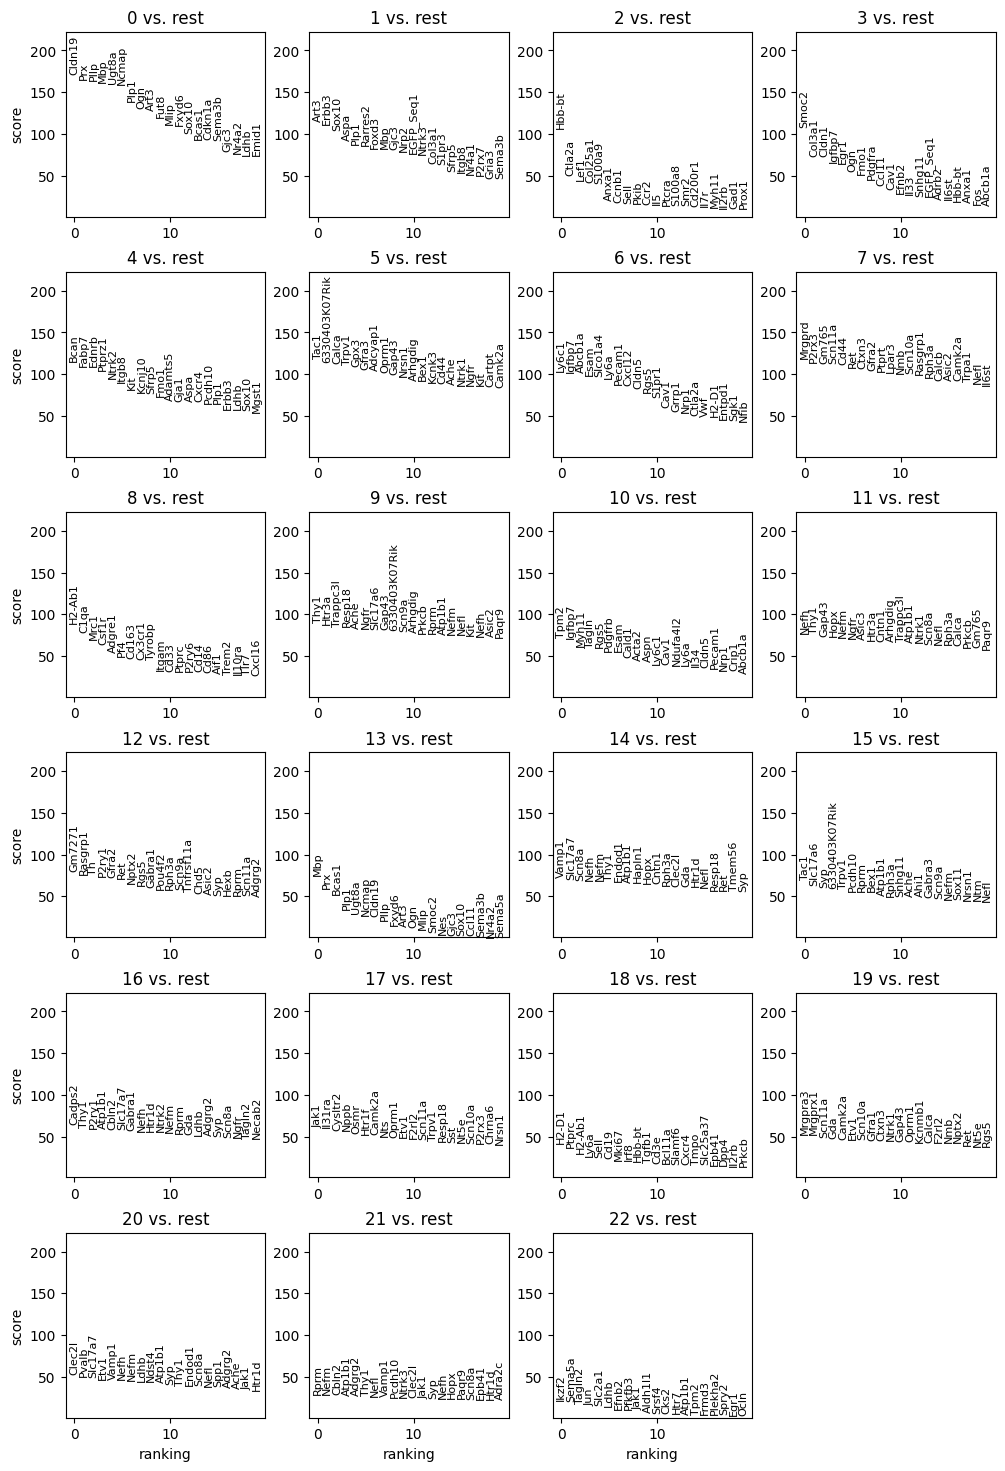

In [18]:
# Visualize top results
sc.pl.rank_genes_groups(adata, groupby = 'leiden_scVI', method = 'wilcoxon')

In [19]:
h5ad_path = os.path.join(output_dir, 'adata-scvi-leiden.h5ad')
adata.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/adata-scvi-leiden.h5ad


### Session info

In [20]:
print('active IDE: sc-charter')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-charter
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
